In this notebook we will look for the following data with the goal of including it into the model: 

+ Location: We could either include coordinates or split it by regions. (coordinates is probably better)
+ Sample type: Sruvey vs. comercial
+ Depth
+ Scale in the image. Probably will not be able to include it here


# Imports and Loading Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium
import ast
# Load the dataset
df_final = pd.read_csv('../../../cod_otolith_age_final_with_quarters.csv')
df_photo = pd.read_csv('/Users/joaodsm/Desktop/Joao Workspace/PhD Compilation/otolith-project/Data/photolith-export.csv')
df_og = pd.read_csv('/Users/joaodsm/Desktop/Joao Workspace/PhD Compilation/otolith-project/Data/cod_otolith_age_cleaned.csv').drop_duplicates(subset=["measurement_id"])

# After analysis we drop na in depth
# df_og = df_og.dropna(subset=["bottom_depth_shot"])

# synaflokkur_nr

df_final
df_photo
df_og

,measurement_id,sample_id_x,station_id,cruise_id,sampleType_number,age,length,weight,sex_number,maturity_number,...,surface_temperature,bottom_depth_shot,bottom_depth_hauled,maturity_status,condition_factor,gsi,hsi,bounding_box,image__content__url,sample_id_y
0,21514156,507573,322736,18797,34,14.0,108,9550.0,1.0,3.0,...,6.0,90.0,88.0,2.0,0.758110,5.633508,4.513089,"[[0, 0], [8256, 5504]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,507573
1,23625439,542618,340495,20498,1,6.0,69,NaN,1.0,4.0,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,"[[2101, 381], [3162, 1010]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,542618
2,23625441,542618,340495,20498,1,7.0,66,NaN,2.0,1.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,"[[4288, 393], [5302, 1022]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,542618
3,23625442,542618,340495,20498,1,7.0,72,NaN,1.0,3.0,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,"[[5332, 381], [6394, 1010]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,542618
4,23625445,542618,340495,20498,1,5.0,65,NaN,2.0,1.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,"[[3366, 1210], [4203, 1839]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,542618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8854,24785922,555106,348573,20745,30,6.0,83,4535.9,2.0,52.0,...,6.3,263.0,256.0,2.0,0.793285,0.529112,1.212549,"[[3948, 2414], [4925, 3043]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,555106
8855,24785923,555106,348573,20745,30,5.0,61,2033.9,2.0,2.0,...,6.3,263.0,256.0,1.0,0.896066,2.753331,9.390826,"[[4959, 2358], [5919, 2987]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,555106
8856,24785995,555106,348573,20745,30,4.0,42,575.0,1.0,1.0,...,6.3,263.0,256.0,0.0,0.776104,NaN,5.913043,"[[5949, 2430], [6721, 3059]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,555106
8857,24786305,555107,348574,20745,30,2.0,24,109.0,1.0,1.0,...,6.4,364.0,403.0,0.0,0.788484,NaN,3.669725,"[[2174, 3296], [2961, 3925]]",https://prod-photolith-s3-civil-hyena.s3.amazo...,555107


# Data Exploration

## Date Analysis

Looking at only the quarter. 

Given we are just around iceland I don't think we need any feature engineering for location features. Geohashing or clustering could be useful but for that we already have the area-grid or the sub-area-grid. Could also use a sin/cos or radial transform but in iceland the variables dont really warp arounf the limits so should be fine to use coordinates. 

In [3]:
df_og["month"].value_counts().sort_values(ascending=False)



month
3     3993
5      814
10     725
11     630
6      463
2      458
9      347
7      317
1      260
4      241
8      215
12     201
Name: count, dtype: int64

Is there any correlation between month and age? 

And between month and age variation? 


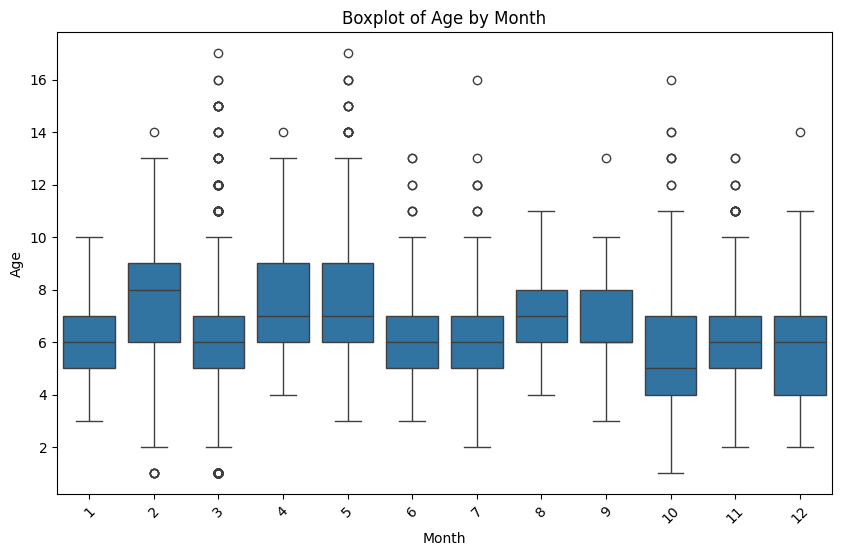

Text(0, 0.5, 'Standard Deviation of Age')

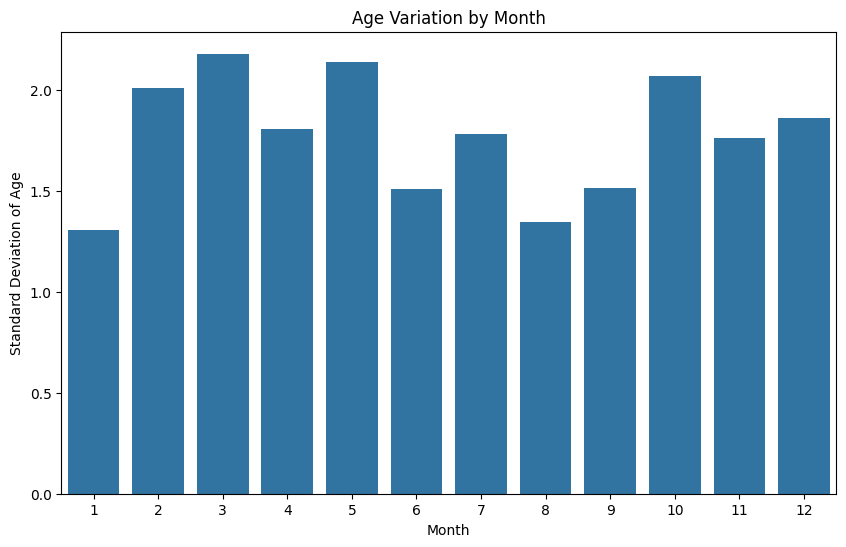

In [4]:
age = df_og["age"].values
month = df_og["month"].values   
plt.figure(figsize=(10, 6))
sns.boxplot(x=month, y=age)
plt.title('Boxplot of Age by Month')
plt.xlabel('Month')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

# Create a plot where we plot age variation by month. We can use the standard deviation of age for each month as a measure of variation.
age_variation = df_og.groupby('month')['age'].std().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='age', data=age_variation)
plt.title('Age Variation by Month')
plt.xlabel('Month')
plt.ylabel('Standard Deviation of Age')         

## Location

Hauled longitude and latitude have some missing values, therefore we will use shot long and lat that seem to be complete. 

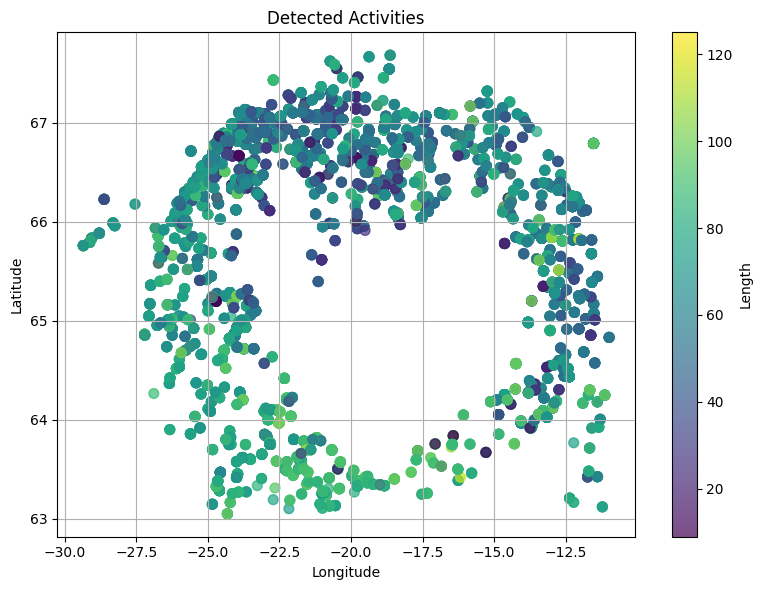

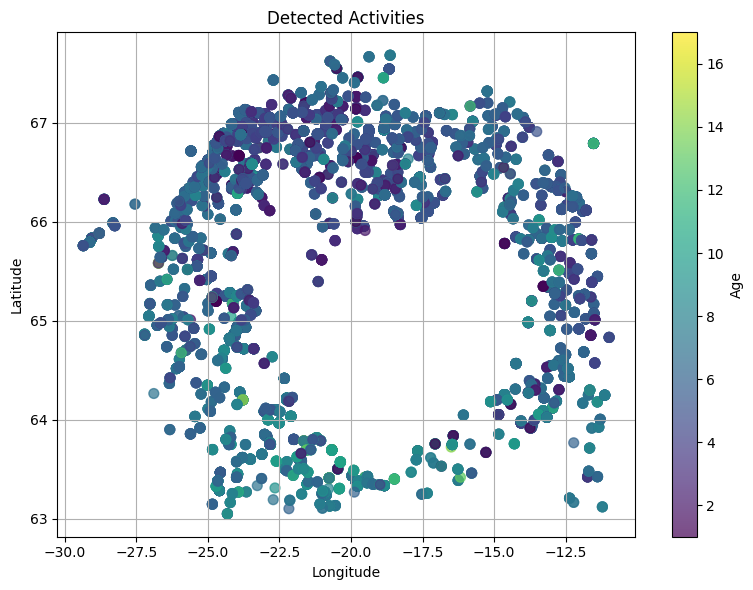

In [5]:


lats = df_og["shot_latitude"].tolist()
lons = df_og["shot_longitude"].tolist()

lengths = df_og["length"].tolist()
ages = df_og["age"].tolist()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(lons, lats, c=lengths, cmap='viridis', marker='o', s=50, alpha=0.7)
plt.colorbar(scatter, label='Length')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Detected Activities')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(lons, lats, c=ages, cmap='viridis', marker='o', s=50, alpha=0.7)
plt.colorbar(scatter, label='Age')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Detected Activities')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
med_lat = 65.5

df_north = df[df["shot_latitude"] >= med_lat]
df_south = df[df["shot_latitude"] < med_lat]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Scatter plots (top row)
for ax, data, title in zip(axes[0], [df, df_north, df_south], ["All Data", "North", "South"]):
    ax.scatter(data["age"], data["length"], alpha=0.5, s=20)
    ax.set_xlabel("Age")
    ax.set_ylabel("Length")
    ax.set_title(title)
    ax.grid(True)

# Single violin plots (bottom row)
for ax, data, title in zip(axes[1], [df, df_north, df_south], ["All Data", "North", "South"]):
    ax.violinplot(data["length"].dropna().values, showmedians=True)
    ax.set_ylabel("Length")
    ax.set_title(f"{title} - Violin")
    ax.set_xticks([])
    ax.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

## Sample Type: Survey vs Commercial

Here I would say it is qure easy. Just understand where is it from a survey and where is it from a comercial and then create a binary variable. 

In [38]:
df_og["sampleType_number"].value_counts()





sampleType_number
30    4126
2     2696
35     705
1      405
8      378
31     351
34       3
Name: count, dtype: int64

In [39]:
df_og["is_survey"] = np.where(df_og["sampleType_number"].isin([30, 31, 35]), True, False)


df_og["is_survey"].value_counts()



is_survey
True     5182
False    3482
Name: count, dtype: int64

/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_69342/2612483500.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_69342/2612483500.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


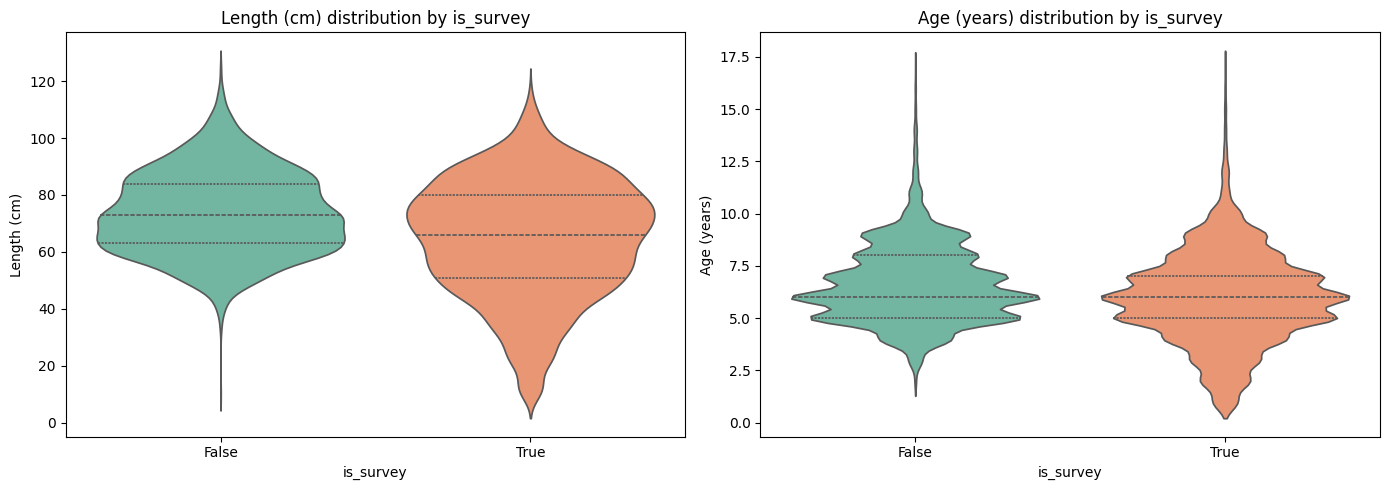

/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_69342/2612483500.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_69342/2612483500.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


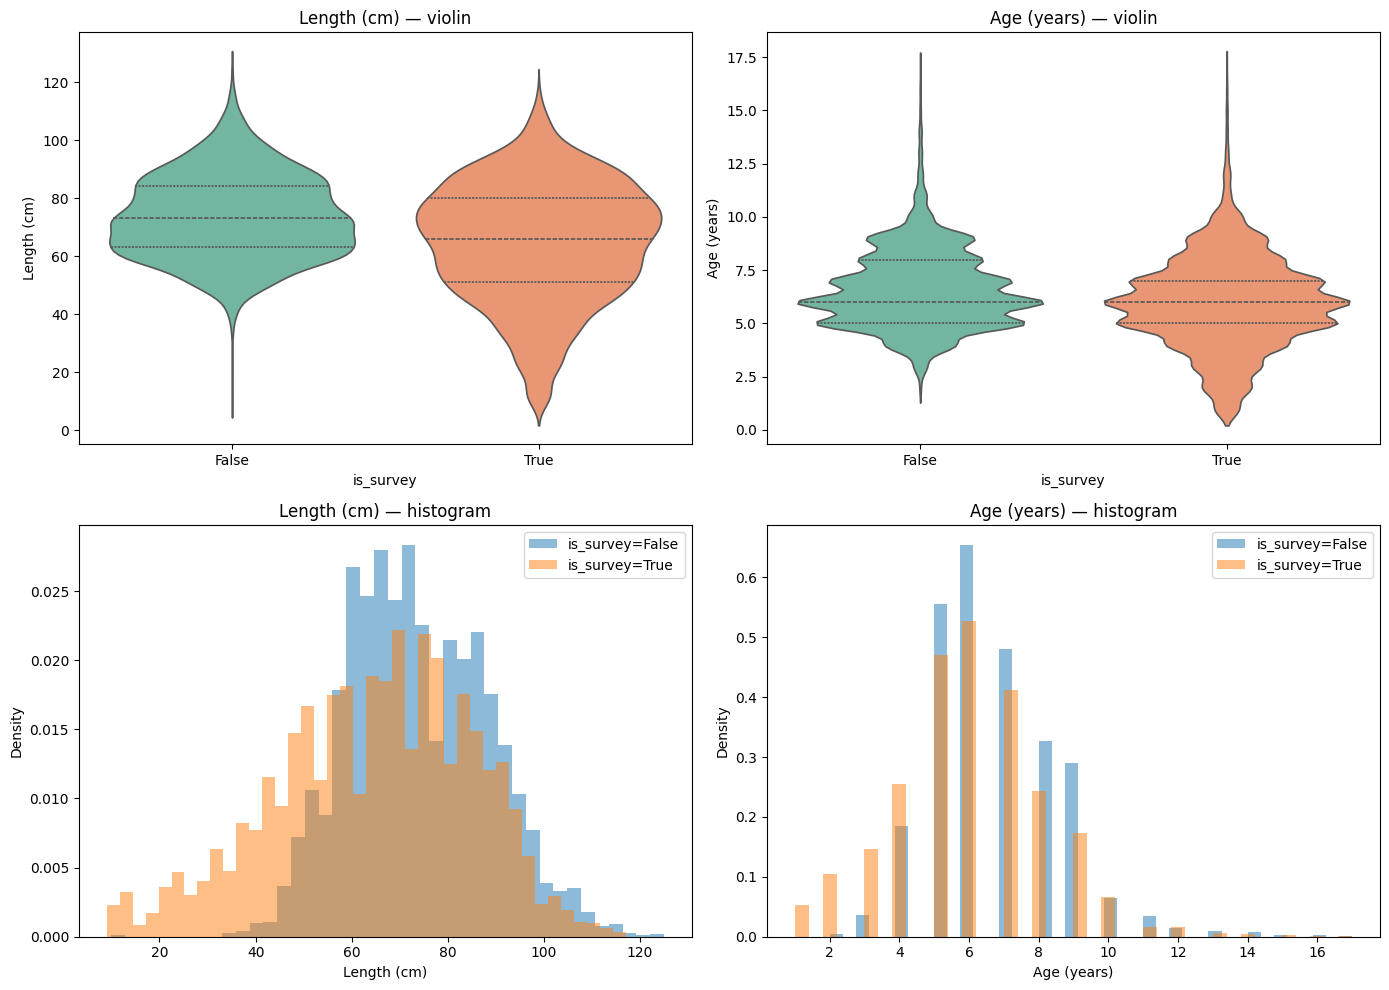

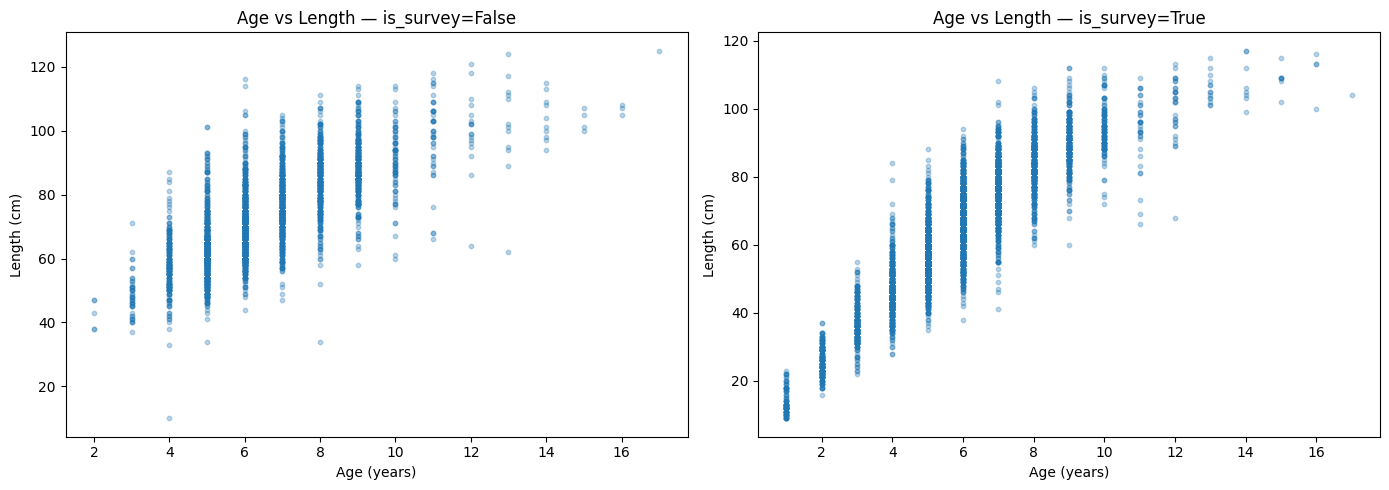

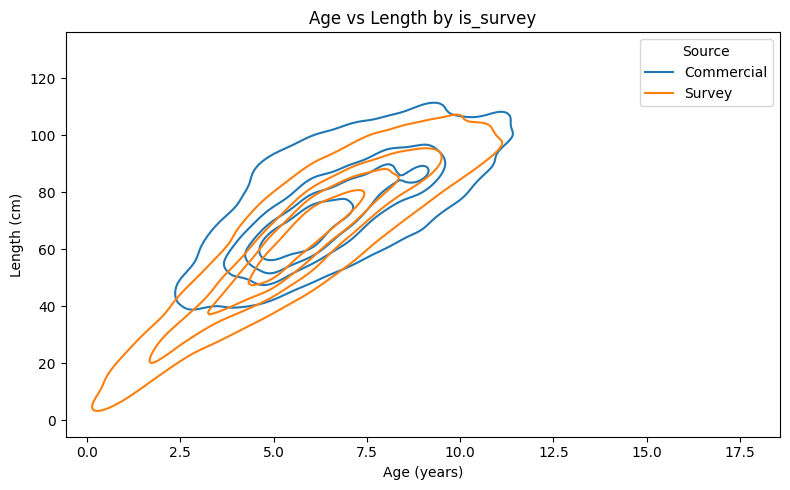

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ["length", "age"], ["Length (cm)", "Age (years)"]):
    sns.violinplot(
        data=df_og,
        x="is_survey",
        y=col,
        ax=ax,
        inner="quartile",   # shows median + IQR lines inside the violin
        palette="Set2",
    )
    ax.set_xlabel("is_survey")
    ax.set_ylabel(label)
    ax.set_title(f"{label} distribution by is_survey")

plt.tight_layout()
plt.show()

# Histograms

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

palette = {"survey": "C0", "commercial": "C1"}  # adjust keys to your actual values

for col_idx, (col, label) in enumerate(zip(["length", "age"], ["Length (cm)", "Age (years)"])):
    # --- Violin ---
    ax_viol = axes[0, col_idx]
    sns.violinplot(
        data=df_og,
        x="is_survey",
        y=col,
        ax=ax_viol,
        inner="quartile",
        palette="Set2",
    )
    ax_viol.set_xlabel("is_survey")
    ax_viol.set_ylabel(label)
    ax_viol.set_title(f"{label} — violin")

    # --- Histogram ---
    ax_hist = axes[1, col_idx]
    for val, grp in df_og.groupby("is_survey"):
        ax_hist.hist(
            grp[col].dropna(),
            bins=40,
            alpha=0.5,
            density=True,
            label=f"is_survey={val}",
        )
    ax_hist.set_xlabel(label)
    ax_hist.set_ylabel("Density")
    ax_hist.set_title(f"{label} — histogram")
    ax_hist.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (val, grp) in zip(axes, df_og.groupby("is_survey")):
    ax.scatter(grp["age"], grp["length"], alpha=0.3, s=10)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Length (cm)")
    ax.set_title(f"Age vs Length — is_survey={val}")

plt.tight_layout()
plt.show()

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 5))


handles = [
    Line2D([0], [0], color=f"C{i}", label=lab)
    for i, lab in enumerate(["Commercial", "Survey"])
]

for val, grp in df_og.groupby("is_survey"):
    label = "Survey" if val else "Commercial"
    sns.kdeplot(data=grp, x="age", y="length", ax=ax, levels=5, label=label)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Length (cm)")
ax.set_title("Age vs Length by is_survey")
ax.legend(handles=handles, title="Source")
plt.tight_layout()
plt.show()

## Gutted Weight (Will not use)

Too many missing values. Could do some inputation by stratifying by age and lenght but probably not worth it. Anways very correlated to length

In [ ]:
# df_og["gutted_weight"].describe()
df_missing_weight = df_og[df_og["gutted_weight"].isna()]

df_missing_weight[["age", "length", "is_survey", "year"]]

,age,length,is_survey,year
1,6.0,69,False,2023
2,7.0,66,False,2023
3,7.0,72,False,2023
4,5.0,65,False,2023
5,6.0,68,False,2023
...,...,...,...,...
8621,1.0,13,True,2025
8626,1.0,12,True,2025
8674,6.0,63,True,2025
8693,3.0,42,True,2025


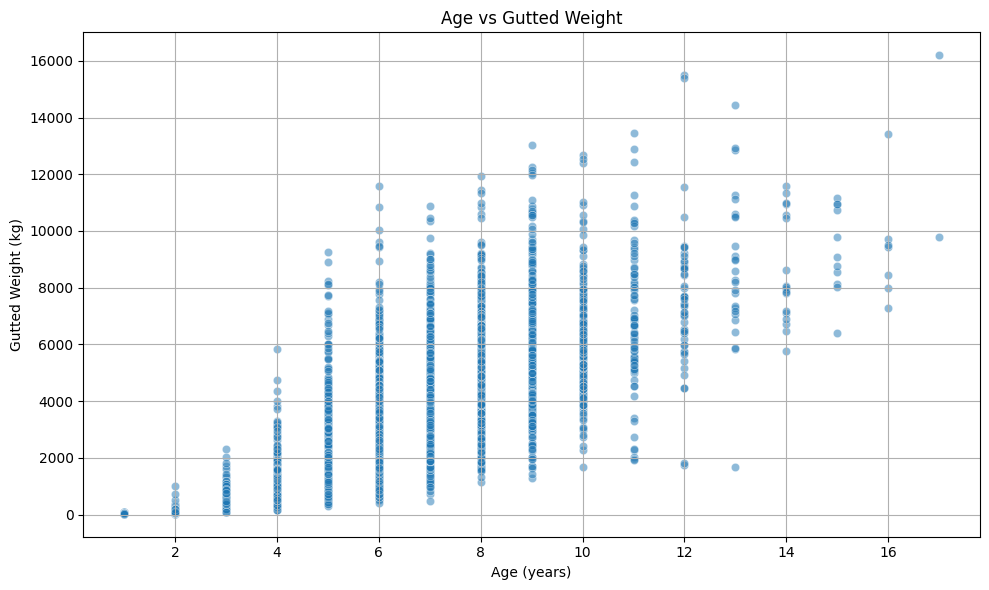

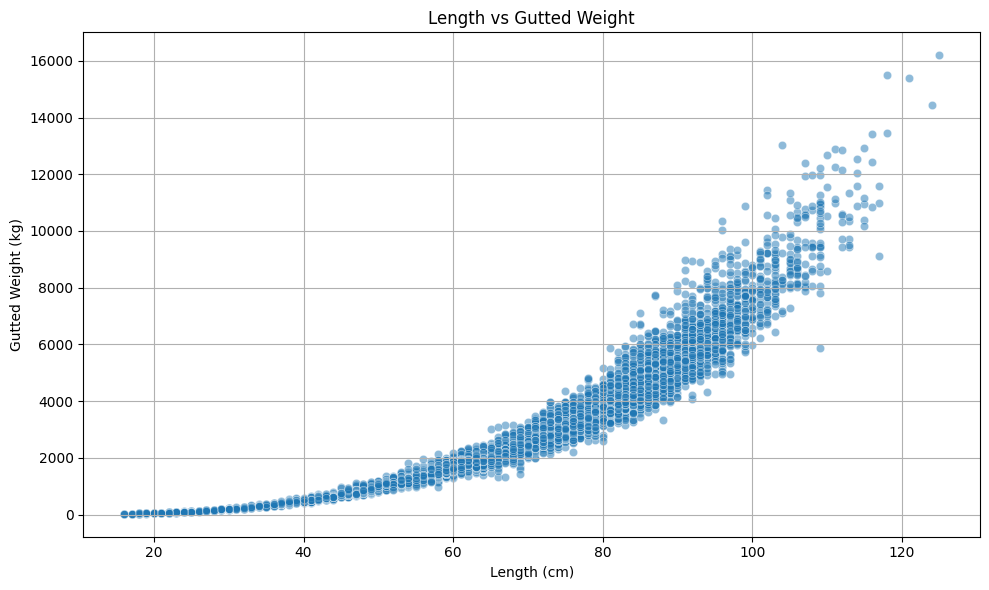

In [ ]:
from matplotlib import figure


fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_og, x="age", y="gutted_weight", alpha=0.5)
plt.title("Age vs Gutted Weight")
plt.xlabel("Age (years)")
plt.ylabel("Gutted Weight (kg)")
plt.grid(True)
plt.tight_layout()
plt.show()  

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_og, x="length", y="gutted_weight", alpha=0.5)
plt.title("Length vs Gutted Weight")
plt.xlabel("Length (cm)")
plt.ylabel("Gutted Weight (kg)")
plt.grid(True)
plt.tight_layout()
plt.show()  

## Depth

## Scale From Database

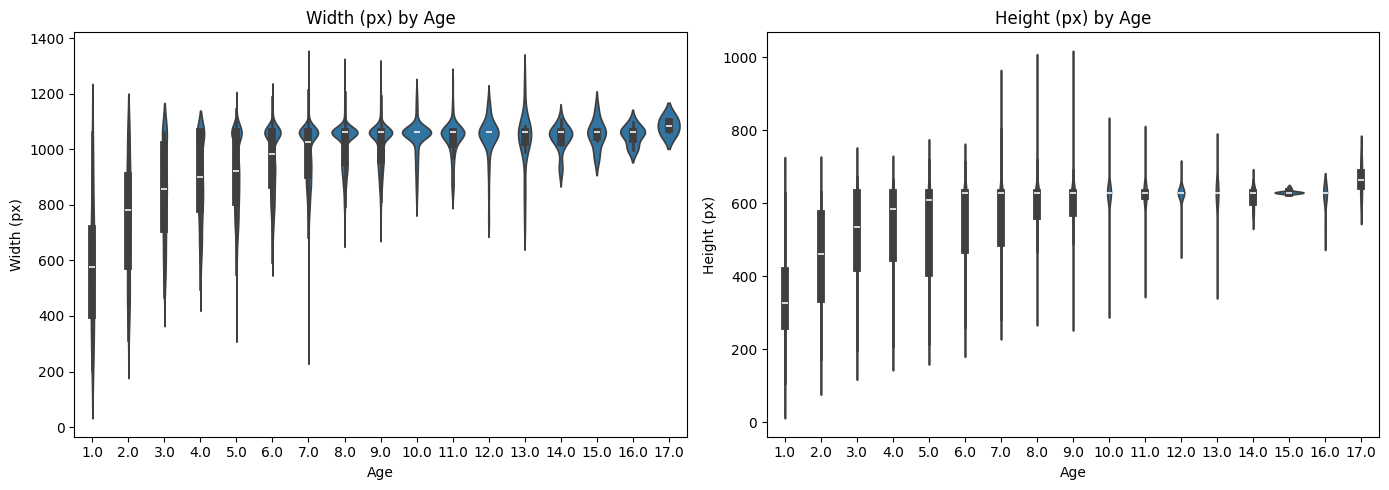

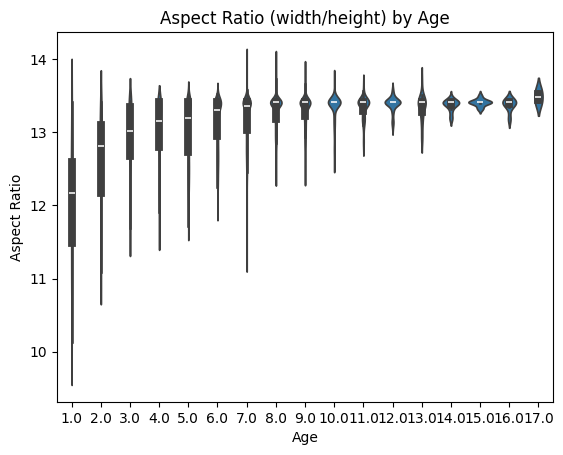

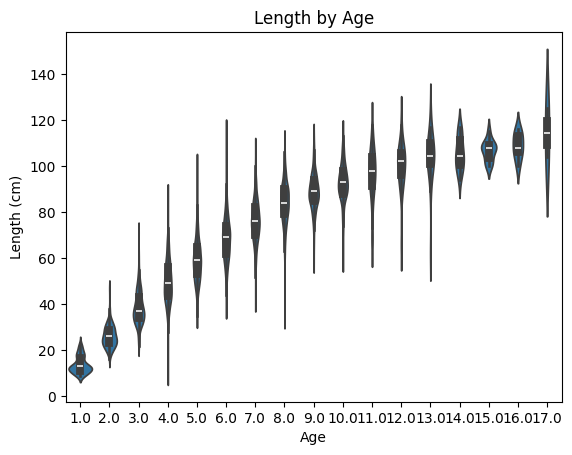

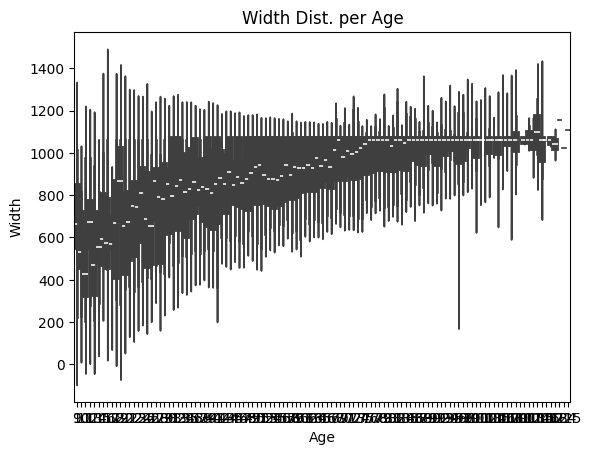

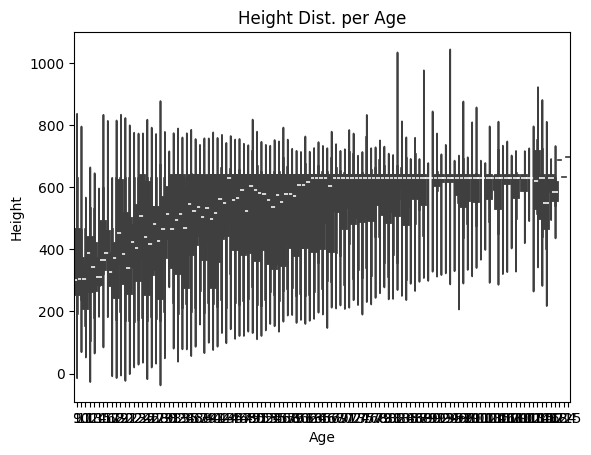

In [10]:

df_scale = pd.read_csv("../../../photolith_with_scale.csv").drop_duplicates(subset=["measureId"])
df_scale = df_scale[df_scale["measureId"].isin(df_og["measurement_id"])].rename(columns={"measureId": "measurement_id"})

def calculate_box_dimensions(bounding_box):
    x_min, y_min = bounding_box[0]
    x_max, y_max = bounding_box[1]
    width = x_max - x_min
    height = y_max - y_min
    return abs(width), abs(height)


df_scale[['width_px', 'height_px']] = df_scale['bounding_box'].apply(
    lambda x: pd.Series(calculate_box_dimensions(ast.literal_eval(x)))
)

df_og = df_og.merge(
    df_scale[['measurement_id', 'width_px', 'height_px']],
    on='measurement_id',
    how='left'
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df_og, x='age', y='width_px', ax=axes[0])
axes[0].set_title('Width (px) by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Width (px)')

sns.violinplot(data=df_og, x='age', y='height_px', ax=axes[1])
axes[1].set_title('Height (px) by Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Height (px)')

plt.tight_layout()
plt.show()

df_og['aspect_ratio'] = np.log(df_og['width_px'] * df_og['height_px'])

sns.violinplot(data=df_og, x='age', y='aspect_ratio')
plt.title('Aspect Ratio (width/height) by Age')
plt.xlabel('Age')
plt.ylabel('Aspect Ratio')
plt.show()


sns.violinplot(data=df_og, x='age', y='length')
plt.title('Length by Age')
plt.xlabel('Age')
plt.ylabel('Length (cm)')
plt.show()


# Width and Height Raw Images
sns.violinplot(data=df_og, x='length', y='width_px')
plt.title('Width Dist. per Age')
plt.xlabel('Age')
plt.ylabel('Width')
plt.show()

sns.violinplot(data=df_og, x='length', y='height_px')
plt.title('Height Dist. per Age')
plt.xlabel('Age')
plt.ylabel('Height')
plt.show()



In [13]:
df_scale

,Unnamed: 0,individual_id,cruise,station,sampleId,measurement_id,individualLabel,id,created_at.x,modified_at.x,...,created_at,modified_at,created_by_id,content,width_px,height_px,seg_width_px_x,seg_height_px_x,seg_width_px_y,seg_height_px_y
0,1,34,TTH1-2024,162,553187,24566535,1,1322.0,12:48.3,12:48.3,...,44:23.1,03:45.2,1,image_content/43811ccb68a6deb66e249fad8c603974...,726.0,418.0,718.0,358.0,718.0,358.0
1,3,35,TTH1-2024,162,553187,24566536,2,1090.0,14:57.9,14:57.9,...,44:23.1,03:45.2,1,image_content/43811ccb68a6deb66e249fad8c603974...,608.0,336.0,566.0,297.0,566.0,297.0
2,5,36,TTH1-2024,162,553187,24566537,3,418.0,25:33.8,25:33.8,...,44:23.1,03:45.2,1,image_content/43811ccb68a6deb66e249fad8c603974...,640.0,288.0,613.0,262.0,613.0,262.0
3,7,37,TTH1-2024,162,553187,24566538,4,1190.0,20:02.6,20:02.6,...,44:23.1,03:45.2,1,image_content/43811ccb68a6deb66e249fad8c603974...,776.0,398.0,770.0,337.0,770.0,337.0
4,9,38,TTH1-2024,162,553187,24566539,5,351.0,43:26.4,43:26.4,...,44:23.1,03:45.2,1,image_content/43811ccb68a6deb66e249fad8c603974...,768.0,329.0,748.0,297.0,748.0,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8658,8967,9202,B3-2023,88,537006,23258607,5,3679.0,36:18.7,36:18.7,...,00:13.1,02:30.0,232,image_content/9aeceb433aeb819ba2457b5277035102...,884.0,539.0,646.0,292.0,646.0,292.0
8659,8968,9203,B3-2023,88,537006,23258618,6,3680.0,37:52.4,37:52.4,...,00:13.1,02:30.0,232,image_content/9aeceb433aeb819ba2457b5277035102...,999.0,556.0,806.0,357.0,806.0,357.0
8660,8969,9204,B3-2023,88,537006,23258633,7,3681.0,38:15.6,38:15.6,...,00:13.1,02:30.0,232,image_content/9aeceb433aeb819ba2457b5277035102...,694.0,460.0,495.0,202.0,495.0,202.0
8661,8970,9205,B3-2023,88,537006,23258636,8,3683.0,39:22.4,39:22.4,...,00:13.1,02:30.0,232,image_content/9aeceb433aeb819ba2457b5277035102...,974.0,460.0,628.0,265.0,628.0,265.0


In [25]:
df_og["seg_width_px"]

0         NaN
1       840.0
2       761.0
3       780.0
4       747.0
        ...  
8659    869.0
8660    743.0
8661    553.0
8662    407.0
8663    790.0
Name: seg_width_px_x, Length: 8664, dtype: float64

Segmented sizes matched: 8619 / 8664


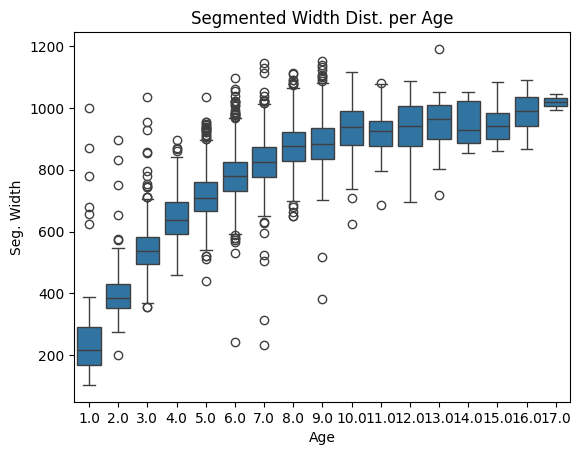

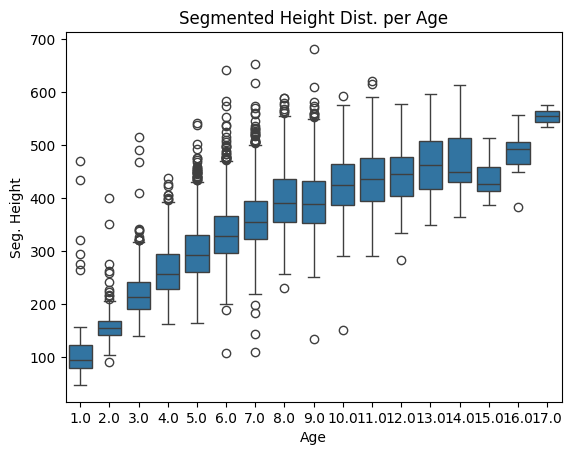

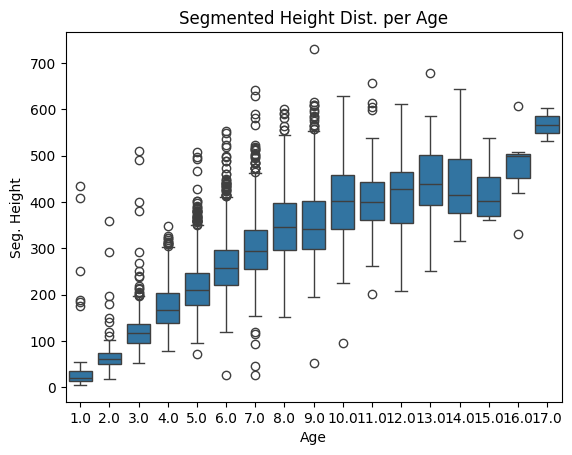

In [35]:
import os

segmented_dir = "../../../otolith_images/segmented_images"
bbox_rows = []

for age_folder in sorted(os.listdir(segmented_dir)):
    bbox_path = os.path.join(segmented_dir, age_folder, "bounding_boxes.csv")
    if os.path.isfile(bbox_path):
        df_bbox = pd.read_csv(bbox_path)
        df_bbox["measurement_id"] = df_bbox["filename"].str.replace(".jpg", "", regex=False).astype(int)
        df_bbox["seg_width_px"] = df_bbox["x2"] - df_bbox["x1"]
        df_bbox["seg_height_px"] = df_bbox["y2"] - df_bbox["y1"]
        bbox_rows.append(df_bbox[["measurement_id", "seg_width_px", "seg_height_px"]])

df_seg_sizes = pd.concat(bbox_rows, ignore_index=True)

# Merge into df_scale
# df_og = df_og.merge(
#     df_seg_sizes,
#     on="measurement_id",
#     how="left"
# )

print(f"Segmented sizes matched: {df_og['seg_width_px'].notna().sum()} / {len(df_og)}")
df_og[["measurement_id", "width_px", "height_px", "seg_width_px", "seg_height_px"]].head(10)

# Width and Height Segmented Images
sns.boxplot(data=df_og, x='age', y='seg_width_px')
plt.title('Segmented Width Dist. per Age')
plt.xlabel('Age')
plt.ylabel('Seg. Width')
plt.show()

sns.boxplot(data=df_og, x='age', y='seg_height_px')
plt.title('Segmented Height Dist. per Age')
plt.xlabel('Age')
plt.ylabel('Seg. Height')
plt.show()

#Aspect Ratio Segmented images
df_og["seg_aspect_ratio"] = df_og["seg_height_px"] * df_og["seg_width_px"] /1000
sns.boxplot(data=df_og, x='age', y='seg_aspect_ratio')
plt.title('Segmented Height Dist. per Age')
plt.xlabel('Age')
plt.ylabel('Seg. Height')
plt.show()



In [ ]:
df_scale["width_px"]

0       726.0
2       608.0
4       640.0
6       776.0
8       768.0
        ...  
8966    884.0
8967    999.0
8968    694.0
8969    974.0
8970    996.0
Name: width_px, Length: 8663, dtype: float64

## Merging features



In [36]:
df_og["month_sin"] = np.sin(2 * np.pi * df_og["month"] / 12)
df_og["month_cos"] = np.cos(2 * np.pi * df_og["month"] / 12)



In [40]:
df_og.to_csv("../../../cod_otolith_age_final_with_scale.csv", index=False)



# Final Dataset

At this point we want to add the following variables to the dataset remove the depthless samples (300 samples). And add into the dataset 

In [ ]:
# df_analysis = df_og[["age", "length", "shot_latitude", "shot_longitude", "bottom_depth_shot", "is_survey", "month"]]

# df_analysis["month_sin"] = np.sin(2 * np.pi * df_analysis["month"] / 12)
# df_analysis["month_cos"] = np.cos(2 * np.pi * df_analysis["month"] / 12)


# df_analysis
# # df_scale[['width_px', 'height_px']]

/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_87644/3855251536.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis["month_sin"] = np.sin(2 * np.pi * df_analysis["month"] / 12)
/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_87644/3855251536.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis["month_cos"] = np.cos(2 * np.pi * df_analysis["month"] / 12)


,age,length,shot_latitude,shot_longitude,bottom_depth_shot,is_survey,month,month_sin,month_cos
0,14.0,108,63.722833,-16.495333,90.0,False,4,8.660254e-01,-5.000000e-01
1,7.0,73,66.200167,-12.341667,216.0,False,12,-2.449294e-16,1.000000e+00
2,6.0,69,66.200167,-12.341667,216.0,False,12,-2.449294e-16,1.000000e+00
3,6.0,72,66.200167,-12.341667,216.0,False,12,-2.449294e-16,1.000000e+00
4,6.0,79,66.200167,-12.341667,216.0,False,12,-2.449294e-16,1.000000e+00
...,...,...,...,...,...,...,...,...,...
8357,6.0,83,66.165000,-25.955167,263.0,True,3,1.000000e+00,6.123234e-17
8358,5.0,61,66.165000,-25.955167,263.0,True,3,1.000000e+00,6.123234e-17
8359,4.0,42,66.165000,-25.955167,263.0,True,3,1.000000e+00,6.123234e-17
8360,2.0,24,66.205500,-26.011167,364.0,True,3,1.000000e+00,6.123234e-17


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, make_scorer

# Drop rows with missing values
df_model = df_analysis.dropna()

X = df_model[["length", "shot_latitude", "shot_longitude", "bottom_depth_shot", "is_survey", "month_sin", "month_cos"]]

y = df_model["age"]

# Pipeline: scale + Ridge with built-in CV over alphas
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5))
])

# Cross-validated scores
cv_mae  = -cross_val_score(pipeline, X, y, cv=10, scoring="neg_mean_absolute_error")
cv_r2   =  cross_val_score(pipeline, X, y, cv=10, scoring="r2")

print(f"CV MAE:  {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"CV R²:   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# Fit on full data to inspect coefficients
pipeline.fit(X, y)
best_alpha = pipeline.named_steps["ridge"].alpha_
coefs      = pipeline.named_steps["ridge"].coef_

print(f"\nBest alpha: {best_alpha}")
print("\nFeature coefficients:")
for feat, coef in zip(X.columns, coefs):
    print(f"  {feat:30s}: {coef:+.4f}")

# Round predictions to nearest integer for classification metrics
y_pred_full = pipeline.predict(X)
y_pred_rounded = np.round(y_pred_full).astype(int)
y_int = y.astype(int)

accuracy = accuracy_score(y_int, y_pred_rounded)
f1_macro = f1_score(y_int, y_pred_rounded, average="macro")
f1_weighted = f1_score(y_int, y_pred_rounded, average="weighted")

print(f"\nAccuracy:     {accuracy:.3f}")
print(f"F1 (macro):   {f1_macro:.3f}")
print(f"F1 (weighted):{f1_weighted:.3f}")

CV MAE:  0.748 ± 0.084
CV R²:   0.747 ± 0.060

Best alpha: 10.0

Feature coefficients:
  length                        : +1.8454
  shot_latitude                 : +0.0056
  shot_longitude                : +0.2201
  bottom_depth_shot             : +0.0278
  is_survey                     : +0.0195
  month_sin                     : +0.2302
  month_cos                     : -0.1810

Accuracy:     0.457
F1 (macro):   0.288
F1 (weighted):0.456


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor

# Helper functions
def rounded_accuracy(y_true, y_pred):
    return accuracy_score(y_true.astype(int), np.round(y_pred).astype(int))

def rounded_f1(y_true, y_pred):
    return f1_score(y_true.astype(int), np.round(y_pred).astype(int), average="macro")

# Pipelines
pipeline_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0], cv=5))
])

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42))
])

for name, pipe in [("Poly Ridge", pipeline_poly), ("GBR", pipeline_gbr)]:
    cv_acc = cross_val_score(pipe, X, y, cv=5, scoring=make_scorer(rounded_accuracy))
    cv_f1  = cross_val_score(pipe, X, y, cv=5, scoring=make_scorer(rounded_f1))
    cv_mae = -cross_val_score(pipe, X, y, cv=5, scoring="neg_mean_absolute_error")
    print(f"{name}: Acc={cv_acc.mean():.3f}, F1={cv_f1.mean():.3f}, MAE={cv_mae.mean():.3f}")

Poly Ridge: Acc=0.449, F1=0.302, MAE=0.743
GBR: Acc=0.459, F1=0.346, MAE=0.733


In [ ]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

models = {
    "Ridge":    pipeline,  # your existing one
    "GBR":      pipeline_gbr,
    "SVM":      Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf", C=10, epsilon=0.1))]),
    "KNN":      Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=5))]),
    "MLP":      Pipeline([("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))]),
}

print(f"{'Model':<12} {'Acc':>6} {'F1 macro':>9} {'MAE':>7}")
print("-" * 38)
for name, pipe in models.items():
    cv_acc = cross_val_score(pipe, X, y, cv=3, scoring=make_scorer(rounded_accuracy))
    cv_f1  = cross_val_score(pipe, X, y, cv=3, scoring=make_scorer(rounded_f1))
    cv_mae = -cross_val_score(pipe, X, y, cv=3, scoring="neg_mean_absolute_error")
    print(f"{name:<12} {cv_acc.mean():>6.3f} {cv_f1.mean():>9.3f} {cv_mae.mean():>7.3f}")

Model           Acc  F1 macro     MAE
--------------------------------------
Ridge         0.454     0.305   0.749
GBR           0.459     0.343   0.740
SVM           0.454     0.333   0.757
KNN           0.421     0.306   0.830
MLP           0.446     0.320   0.754


In [ ]:
from sklearn.model_selection import GridSearchCV

svm_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])

param_grid = {
    "model__C":       [1, 10, 50, 100],
    "model__epsilon": [0.05, 0.1, 0.5],
    "model__gamma":   ["scale", "auto"]
}

gs = GridSearchCV(svm_grid, param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1, verbose=1)
gs.fit(X, y)

print(f"Best params: {gs.best_params_}")
print(f"Best MAE:    {-gs.best_score_:.3f}")

# Evaluate best model with all metrics
best_svm = gs.best_estimator_
cv_acc = cross_val_score(best_svm, X, y, cv=3, scoring=make_scorer(rounded_accuracy))
cv_f1  = cross_val_score(best_svm, X, y, cv=3, scoring=make_scorer(rounded_f1))
cv_mae = -cross_val_score(best_svm, X, y, cv=3, scoring="neg_mean_absolute_error")
print(f"\nSVM (tuned): Acc={cv_acc.mean():.3f}, F1={cv_f1.mean():.3f}, MAE={cv_mae.mean():.3f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'model__C': 1, 'model__epsilon': 0.1, 'model__gamma': 'auto'}
Best MAE:    0.740

SVM (tuned): Acc=0.456, F1=0.320, MAE=0.740
